In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib import rcParams
import warnings

warnings.filterwarnings('ignore')

# Pengaturan tampilan pandas agar tabel lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width', 120)

# Pengaturan style matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 11

print('✅ Semua library berhasil diimport!')
print(f'   • NumPy  versi : {np.__version__}')
print(f'   • Pandas versi : {pd.__version__}')

✅ Semua library berhasil diimport!
   • NumPy  versi : 2.0.2
   • Pandas versi : 2.2.2


In [4]:
from google.colab import files

print('📤 Silakan upload file: Rekap_Transaksi_Greyclean_2026.xlsx')
uploaded = files.upload()

# Ambil nama file yang diupload
nama_file = list(uploaded.keys())[0]
print(f'\n✅ File berhasil diupload: {nama_file}')

# ------------------------------------------------------------------
# Baca semua nama sheet
# ------------------------------------------------------------------
xl = pd.ExcelFile(nama_file)
print(f'\n📋 Sheet yang tersedia:')
for i, s in enumerate(xl.sheet_names, 1):
    print(f'   {i}. {s}')

📤 Silakan upload file: Rekap_Transaksi_Greyclean_2026.xlsx


Saving Rekap_Transaksi_Greyclean_2026.xlsx to Rekap_Transaksi_Greyclean_2026.xlsx

✅ File berhasil diupload: Rekap_Transaksi_Greyclean_2026.xlsx

📋 Sheet yang tersedia:
   1. Januari 2026
   2. Febuari 2026
   3. Maret 2026
   4. April 2026


In [5]:
# ============================================================
# PREPROCESSING DATA
# ============================================================
# Tujuan:
#   - Membersihkan header dan baris kosong dari setiap sheet
#   - Menggabungkan semua sheet menjadi satu DataFrame
#   - Standardisasi nama pelanggan
#   - Filter hanya pelanggan dengan >= 2 transaksi

print('=' * 60)
print('  PREPROCESSING DATA')
print('=' * 60)

all_data = []  # Tampung data dari semua sheet

for sheet in xl.sheet_names:
    # Baca tanpa header karena ada baris judul di atas
    df_raw = pd.read_excel(xl, sheet_name=sheet, header=None)

    # Ambil data mulai baris ke-6 (index 5), skip baris header & judul
    df = df_raw.iloc[5:].copy()
    df.columns = ['No_Transaksi', 'Tanggal', 'Nama_Pelanggan',
                  'No_HP', 'Metode_Pembayaran', 'Nama_Barang',
                  'Tipe_Treatment', 'Total_Harga']

    # Tambahkan kolom bulan
    df['Bulan'] = sheet

    # Filter: hanya baris yang kolom No_Transaksi berisi angka valid
    df = df[df['No_Transaksi'].apply(
        lambda x: str(x).strip().replace('.0', '').isdigit() if pd.notna(x) else False
    )].copy()

    all_data.append(df)
    print(f'  ✔ {sheet:20s} → {len(df):3d} transaksi dimuat')

# ---- Gabungkan semua sheet ----
df_all = pd.concat(all_data, ignore_index=True)
print(f'\n  📊 Total transaksi gabungan : {len(df_all)} baris')

# ---- Pembersihan kolom Total_Harga ----
df_all['Total_Harga'] = pd.to_numeric(df_all['Total_Harga'], errors='coerce')
baris_harga_kosong = df_all['Total_Harga'].isna().sum()
df_all.dropna(subset=['Total_Harga'], inplace=True)
print(f'  🗑  Baris harga kosong dihapus : {baris_harga_kosong}')

# ---- Standardisasi nama pelanggan ----
# Ubah ke Title Case agar "bu desi" == "Bu Desi"
df_all['Nama_Pelanggan'] = df_all['Nama_Pelanggan'].astype(str).str.strip().str.title()

# Hapus baris dengan nama tidak valid
df_all = df_all[~df_all['Nama_Pelanggan'].isin(['-', 'Nan', 'None', ''])]
print(f'  👤 Total pelanggan unik       : {df_all["Nama_Pelanggan"].nunique()}')

# ---- Filter pelanggan >= 2 transaksi ----
frekuensi = df_all.groupby('Nama_Pelanggan').size()
pelanggan_loyal = frekuensi[frekuensi >= 2].index
df_loyal = df_all[df_all['Nama_Pelanggan'].isin(pelanggan_loyal)].copy()

print(f'  🏅 Pelanggan >= 2 transaksi   : {len(pelanggan_loyal)} orang')
print(f'  📦 Total transaksi dianalisis : {len(df_loyal)} transaksi')

print('\n' + '=' * 60)
print('  PREVIEW DATA BERSIH (10 baris pertama)')
print('=' * 60)

# Tampilkan 2 sampel per bulan agar terlihat semua bulan
sampel = df_loyal.groupby('Bulan').head(2)[['No_Transaksi', 'Bulan',
          'Nama_Pelanggan', 'Tipe_Treatment', 'Total_Harga']]
display(sampel)

# Konfirmasi jumlah transaksi per bulan
print('\n  Jumlah transaksi per bulan:')
print(df_loyal.groupby('Bulan').size().to_string())

  PREPROCESSING DATA
  ✔ Januari 2026         →  70 transaksi dimuat
  ✔ Febuari 2026         →  41 transaksi dimuat
  ✔ Maret 2026           →  39 transaksi dimuat
  ✔ April 2026           →  48 transaksi dimuat

  📊 Total transaksi gabungan : 198 baris
  🗑  Baris harga kosong dihapus : 1
  👤 Total pelanggan unik       : 158
  🏅 Pelanggan >= 2 transaksi   : 26 orang
  📦 Total transaksi dianalisis : 64 transaksi

  PREVIEW DATA BERSIH (10 baris pertama)


,No_Transaksi,Bulan,Nama_Pelanggan,Tipe_Treatment,Total_Harga
3,4,Januari 2026,Valentin,Deep Clean,"50,000.00"
5,6,Januari 2026,Bu Desi,Deep Clean & Repair,"50,000.00"
70,1,Febuari 2026,Drajat,Premium Service,"120,000.00"
75,6,Febuari 2026,Bu Dewi,Fast Clean,"30,000.00"
114,4,Maret 2026,Valentin,Premium Service,"100,000.00"
117,7,Maret 2026,Ali,Deep Clean,"50,000.00"
166,17,April 2026,Dio,Express Service,"325,000.00"
167,18,April 2026,Nona,Deep Clean,"50,000.00"



  Jumlah transaksi per bulan:
Bulan
April 2026      12
Febuari 2026    14
Januari 2026    22
Maret 2026      16


In [6]:
# ============================================================
# AGREGASI PER PELANGGAN → MATRIKS KEPUTUSAN
# ============================================================

df_matrix = df_loyal.groupby('Nama_Pelanggan').agg(
    C1_Total_Transaksi   = ('No_Transaksi', 'count'),
    C2_Total_Pengeluaran = ('Total_Harga', 'sum'),
    C3_Rata_Rata_Harga   = ('Total_Harga', 'mean'),
    C4_Variasi_Treatment = ('Tipe_Treatment', lambda x: x.dropna().nunique())
).reset_index()

# Urutkan berdasarkan nama
df_matrix = df_matrix.sort_values('Nama_Pelanggan').reset_index(drop=True)
df_matrix.index = df_matrix.index + 1

print('=' * 70)
print('  MATRIKS KEPUTUSAN (Decision Matrix)')
print('=' * 70)
print('  C1 = Total Transaksi    | C2 = Total Pengeluaran (IDR)')
print('  C3 = Rata-rata Harga    | C4 = Variasi Treatment')
print('  Semua kriteria : BENEFIT (semakin besar = semakin baik)')
print('=' * 70)

# Format tampilan
df_tampil = df_matrix.copy()
df_tampil['C2_Total_Pengeluaran'] = df_tampil['C2_Total_Pengeluaran'].apply(
    lambda x: f'Rp {x:,.0f}'
)
df_tampil['C3_Rata_Rata_Harga'] = df_tampil['C3_Rata_Rata_Harga'].apply(
    lambda x: f'Rp {x:,.0f}'
)
df_tampil.columns = ['Nama Pelanggan', 'C1\nTotal Transaksi',
                     'C2\nTotal Pengeluaran', 'C3\nRata-rata Harga',
                     'C4\nVariasi Treatment']
display(df_tampil)
print(f'\n  Total pelanggan yang dianalisis: {len(df_matrix)} orang')

  MATRIKS KEPUTUSAN (Decision Matrix)
  C1 = Total Transaksi    | C2 = Total Pengeluaran (IDR)
  C3 = Rata-rata Harga    | C4 = Variasi Treatment
  Semua kriteria : BENEFIT (semakin besar = semakin baik)


,Nama Pelanggan,C1\nTotal Transaksi,C2\nTotal Pengeluaran,C3\nRata-rata Harga,C4\nVariasi Treatment
1,Adam,2,"Rp 150,000","Rp 75,000",2
2,Adit,2,"Rp 200,000","Rp 100,000",1
3,Ali,2,"Rp 150,000","Rp 75,000",1
4,Ayu,2,"Rp 300,000","Rp 150,000",2
5,Bapak Haikal,3,"Rp 300,000","Rp 100,000",1
6,Bu Desi,4,"Rp 330,000","Rp 82,500",2
7,Bu Dewi,2,"Rp 90,000","Rp 45,000",2
8,Buderi,2,"Rp 160,000","Rp 80,000",2
9,Cakra,2,"Rp 340,000","Rp 170,000",2
10,Dewo,2,"Rp 250,000","Rp 125,000",1



  Total pelanggan yang dianalisis: 26 orang


In [7]:
# ============================================================
# SEL 5: PENGATURAN BOBOT KRITERIA
# ============================================================
# Total bobot HARUS = 1.0 (100%)
print('=' * 60)
print('  PENGATURAN BOBOT KRITERIA')
print('=' * 60)

# ==============================================================
# 🔧 UBAH DI SINI JIKA INGIN BOBOT KUSTOM (total harus = 1.0)
# ==============================================================
GUNAKAN_BOBOT_CUSTOM = False   # Ganti True untuk pakai bobot kustom

# -- Bobot Default --
bobot_default = np.array([0.30, 0.35, 0.20, 0.15])
#                           C1     C2    C3    C4

# -- Bobot Custom (edit sesuai kebutuhan) --
bobot_custom  = np.array([0.25, 0.40, 0.20, 0.15])
#                           C1    C2    C3    C4

# -- Pilih bobot yang digunakan --
if GUNAKAN_BOBOT_CUSTOM:
    bobot = bobot_custom
    jenis_bobot = 'KUSTOM'
else:
    bobot = bobot_default
    jenis_bobot = 'DEFAULT'

# Validasi total bobot harus = 1
assert abs(bobot.sum() - 1.0) < 1e-9, '❌ ERROR: Total bobot harus = 1.0!'

nama_kriteria  = ['C1 - Total Transaksi', 'C2 - Total Pengeluaran',
                  'C3 - Rata-rata Harga', 'C4 - Variasi Treatment']
jenis_kriteria = ['Benefit', 'Benefit', 'Benefit', 'Benefit']

print(f'\n  Mode bobot yang digunakan: {jenis_bobot}')
print(f'  {"":4s} {"Kriteria":25s} {"Tipe":10s} {"Bobot":>8s} {"Persentase":>12s}')
print(f'  {"-"*65}')
for i, (nama, jenis, w) in enumerate(zip(nama_kriteria, jenis_kriteria, bobot), 1):
    bar = '█' * int(w * 40)
    print(f'  {i:<4d} {nama:<25s} {jenis:<10s} {w:>8.2f} {w*100:>10.1f}%  {bar}')
print(f'  {"-"*65}')
print(f'  {"":4s} {"TOTAL":25s} {"":10s} {bobot.sum():>8.2f} {bobot.sum()*100:>10.1f}%')
print(f'\n  ✅ Validasi bobot: OK (total = {bobot.sum():.2f})')

  PENGATURAN BOBOT KRITERIA

  Mode bobot yang digunakan: DEFAULT
       Kriteria                  Tipe          Bobot   Persentase
  -----------------------------------------------------------------
  1    C1 - Total Transaksi      Benefit        0.30       30.0%  ████████████
  2    C2 - Total Pengeluaran    Benefit        0.35       35.0%  ██████████████
  3    C3 - Rata-rata Harga      Benefit        0.20       20.0%  ████████
  4    C4 - Variasi Treatment    Benefit        0.15       15.0%  ██████
  -----------------------------------------------------------------
       TOTAL                                    1.00      100.0%

  ✅ Validasi bobot: OK (total = 1.00)


In [8]:
# ============================================================
# SEL 6: NORMALISASI MATRIKS
# ============================================================

# Ambil nilai numerik dari matriks keputusan
X = df_matrix[['C1_Total_Transaksi', 'C2_Total_Pengeluaran',
               'C3_Rata_Rata_Harga', 'C4_Variasi_Treatment']].values.astype(float)

n_alt  = X.shape[0]   # Jumlah alternatif (pelanggan)
n_krit = X.shape[1]   # Jumlah kriteria

# Hitung akar dari jumlah kuadrat setiap kolom
penyebut = np.sqrt((X ** 2).sum(axis=0))

# Normalisasi
R = X / penyebut

# DataFrame untuk tampilan
df_R = pd.DataFrame(
    R,
    index   = df_matrix['Nama_Pelanggan'].values,
    columns = ['C1', 'C2', 'C3', 'C4']
)

print('=' * 70)
print('  MATRIKS TERNORMALISASI (R)')
print('  Rumus: r_ij = x_ij / sqrt(Σ x_ij²)')
print('=' * 70)
display(df_R.round(6))

# Verifikasi: jumlah kuadrat setiap kolom harus = 1
verif = (R ** 2).sum(axis=0)
print('\n  Verifikasi normalisasi (jumlah kuadrat per kolom, harus ≈ 1.0):')
for nm, v in zip(['C1', 'C2', 'C3', 'C4'], verif):
    status = '✅' if abs(v - 1.0) < 1e-9 else '❌'
    print(f'  {status}  {nm} = {v:.10f}')

  MATRIKS TERNORMALISASI (R)
  Rumus: r_ij = x_ij / sqrt(Σ x_ij²)


,C1,C2,C3,C4
Adam,0.15,0.09,0.12,0.21
Adit,0.15,0.13,0.16,0.11
Ali,0.15,0.09,0.12,0.11
Ayu,0.15,0.19,0.25,0.21
Bapak Haikal,0.22,0.19,0.16,0.11
Bu Desi,0.30,0.21,0.14,0.21
Bu Dewi,0.15,0.06,0.07,0.21
Buderi,0.15,0.10,0.13,0.21
Cakra,0.15,0.21,0.28,0.21
Dewo,0.15,0.16,0.21,0.11



  Verifikasi normalisasi (jumlah kuadrat per kolom, harus ≈ 1.0):
  ✅  C1 = 1.0000000000
  ✅  C2 = 1.0000000000
  ✅  C3 = 1.0000000000
  ✅  C4 = 1.0000000000


In [9]:
# ============================================================
# SEL 7: MATRIKS TERNORMALISASI TERBOBOT (V)
# ============================================================

# Kalikan matriks R dengan bobot
V = R * bobot

# DataFrame untuk tampilan
df_V = pd.DataFrame(
    V,
    index   = df_matrix['Nama_Pelanggan'].values,
    columns = ['C1', 'C2', 'C3', 'C4']
)

print('=' * 70)
print('  MATRIKS TERNORMALISASI TERBOBOT (V)')
print(f'  Bobot: C1={bobot[0]}, C2={bobot[1]}, C3={bobot[2]}, C4={bobot[3]}')
print('  Rumus: v_ij = w_j × r_ij')
print('=' * 70)
display(df_V.round(6))

print('\n  Ringkasan nilai per kolom:')
print(f'  {"Kriteria":8s} {"Min":>12s} {"Max":>12s} {"Mean":>12s}')
print(f'  {"-"*48}')
for j, nm in enumerate(['C1', 'C2', 'C3', 'C4']):
    print(f'  {nm:<8s} {V[:,j].min():>12.6f} {V[:,j].max():>12.6f} {V[:,j].mean():>12.6f}')

  MATRIKS TERNORMALISASI TERBOBOT (V)
  Bobot: C1=0.3, C2=0.35, C3=0.2, C4=0.15
  Rumus: v_ij = w_j × r_ij


,C1,C2,C3,C4
Adam,0.04,0.03,0.02,0.03
Adit,0.04,0.04,0.03,0.02
Ali,0.04,0.03,0.02,0.02
Ayu,0.04,0.07,0.05,0.03
Bapak Haikal,0.07,0.07,0.03,0.02
Bu Desi,0.09,0.07,0.03,0.03
Bu Dewi,0.04,0.02,0.01,0.03
Buderi,0.04,0.04,0.03,0.03
Cakra,0.04,0.08,0.06,0.03
Dewo,0.04,0.06,0.04,0.02



  Ringkasan nilai per kolom:
  Kriteria          Min          Max         Mean
  ------------------------------------------------
  C1           0.044972     0.134916     0.055350
  C2           0.019859     0.172115     0.057753
  C3           0.014822     0.096341     0.034837
  C4           0.015811     0.047434     0.027974


In [10]:
# ============================================================
# SEL 8: SOLUSI IDEAL POSITIF (A+) DAN NEGATIF (A−)
# ============================================================
# A+ = nilai terbaik tiap kriteria
#   → Benefit : nilai MAKSIMUM
#   → Cost    : nilai MINIMUM
#
# A− = nilai terburuk tiap kriteria
#   → Benefit : nilai MINIMUM
#   → Cost    : nilai MAKSIMUM
#
# Karena SEMUA kriteria adalah BENEFIT:
#   A+ = max setiap kolom
#   A− = min setiap kolom

is_benefit = [True, True, True, True]

A_plus  = np.where(is_benefit, V.max(axis=0), V.min(axis=0))
A_minus = np.where(is_benefit, V.min(axis=0), V.max(axis=0))

# Nama pelanggan pemilik nilai A+ dan A− per kriteria
idx_plus  = V.argmax(axis=0)
idx_minus = V.argmin(axis=0)
nama_list = df_matrix['Nama_Pelanggan'].values

print('=' * 70)
print('  SOLUSI IDEAL POSITIF (A+) & NEGATIF (A−)')
print('=' * 70)
print(f'\n  {"Kriteria":10s} {"Tipe":10s} {"A+ (Terbaik)":>14s} {"Oleh":20s} {"A− (Terburuk)":>14s} {"Oleh":20s}')
print(f'  {"-"*90}')

for j, (nm, ib) in enumerate(zip(['C1', 'C2', 'C3', 'C4'], is_benefit)):
    tipe = 'Benefit' if ib else 'Cost'
    print(f'  {nm:<10s} {tipe:<10s} {A_plus[j]:>14.6f} {nama_list[idx_plus[j]]:<20s} '
          f'{A_minus[j]:>14.6f} {nama_list[idx_minus[j]]:<20s}')

print(f'\n  A+ = {np.array2string(A_plus,  precision=6, separator=", ")}')
print(f'  A− = {np.array2string(A_minus, precision=6, separator=", ")}')

  SOLUSI IDEAL POSITIF (A+) & NEGATIF (A−)

  Kriteria   Tipe         A+ (Terbaik) Oleh                  A− (Terburuk) Oleh                
  ------------------------------------------------------------------------------------------
  C1         Benefit          0.134916 Rizki                      0.044972 Adam                
  C2         Benefit          0.172115 Rizki                      0.019859 Bu Dewi             
  C3         Benefit          0.096341 Dio                        0.014822 Bu Dewi             
  C4         Benefit          0.047434 Marsha                     0.015811 Adit                

  A+ = [0.134916, 0.172115, 0.096341, 0.047434]
  A− = [0.044972, 0.019859, 0.014822, 0.015811]


In [11]:
# ============================================================
# SEL 9: JARAK SEPARASI (D+ dan D−)
# ============================================================
# Hitung jarak setiap alternatif ke solusi ideal positif (D+)
# dan ke solusi ideal negatif (D−) menggunakan jarak Euclidean.
#
# Rumus:
#   D+_i = sqrt(Σ (v_ij − A+_j)²)
#   D−_i = sqrt(Σ (v_ij − A−_j)²)

D_plus  = np.sqrt(((V - A_plus)  ** 2).sum(axis=1))
D_minus = np.sqrt(((V - A_minus) ** 2).sum(axis=1))

df_jarak = pd.DataFrame({
    'Nama Pelanggan'  : nama_list,
    'D+ (Jarak ke A+)': D_plus,
    'D− (Jarak ke A−)': D_minus
})
df_jarak.index = range(1, len(df_jarak) + 1)

print('=' * 70)
print('  JARAK SEPARASI')
print('  D+ = Jarak ke Solusi Ideal Positif (semakin kecil = semakin baik)')
print('  D− = Jarak ke Solusi Ideal Negatif (semakin besar = semakin baik)')
print('  Rumus: D+_i = sqrt(Σ(v_ij − A+_j)²)')
print('=' * 70)
display(df_jarak.round(6))

print(f'\n  Pelanggan dengan D+ terkecil : '
      f'{nama_list[D_plus.argmin()]} ({D_plus.min():.6f})')
print(f'  Pelanggan dengan D− terbesar : '
      f'{nama_list[D_minus.argmax()]} ({D_minus.max():.6f})')

  JARAK SEPARASI
  D+ = Jarak ke Solusi Ideal Positif (semakin kecil = semakin baik)
  D− = Jarak ke Solusi Ideal Negatif (semakin besar = semakin baik)
  Rumus: D+_i = sqrt(Σ(v_ij − A+_j)²)


,Nama Pelanggan,D+ (Jarak ke A+),D− (Jarak ke A−)
1,Adam,0.18,0.02
2,Adit,0.17,0.03
3,Ali,0.18,0.02
4,Ayu,0.15,0.06
5,Bapak Haikal,0.14,0.05
6,Bu Desi,0.13,0.07
7,Bu Dewi,0.20,0.02
8,Buderi,0.18,0.02
9,Cakra,0.14,0.07
10,Dewo,0.16,0.04



  Pelanggan dengan D+ terkecil : Rizki (0.053523)
  Pelanggan dengan D− terbesar : Rizki (0.181811)


In [12]:
# ============================================================
# SEL 10: NILAI PREFERENSI (Ci) DAN RANKING AKHIR
# ============================================================
# Rumus:
#   Ci = D−_i / (D+_i + D−_i)
#
# Nilai Ci berkisar antara 0 dan 1:
#   Ci → 1 : mendekati solusi ideal positif (TERBAIK)
#   Ci → 0 : mendekati solusi ideal negatif (TERBURUK)

Ci = D_minus / (D_plus + D_minus)

df_hasil = pd.DataFrame({
    'Nama Pelanggan'        : nama_list,
    'D+ (ke Ideal+)'        : D_plus,
    'D− (ke Ideal−)'        : D_minus,
    'Nilai Preferensi (Ci)' : Ci,
    'Ranking'               : Ci.argsort()[::-1].argsort() + 1
})

# Gabungkan dengan data asli
df_hasil = df_hasil.merge(
    df_matrix[['Nama_Pelanggan', 'C1_Total_Transaksi',
               'C2_Total_Pengeluaran', 'C3_Rata_Rata_Harga',
               'C4_Variasi_Treatment']],
    left_on='Nama Pelanggan', right_on='Nama_Pelanggan'
).drop('Nama_Pelanggan', axis=1)

df_hasil.sort_values('Ranking', inplace=True)
df_hasil = df_hasil.reset_index(drop=True)
df_hasil.index = range(1, len(df_hasil) + 1)

# Tampilkan dengan color gradient
kolom_tampil = ['Nama Pelanggan', 'C1_Total_Transaksi',
                'C2_Total_Pengeluaran', 'C3_Rata_Rata_Harga',
                'C4_Variasi_Treatment', 'D+ (ke Ideal+)',
                'D− (ke Ideal−)', 'Nilai Preferensi (Ci)', 'Ranking']

df_tampil_hasil = df_hasil[kolom_tampil].copy()
df_tampil_hasil.columns = ['Nama Pelanggan', 'C1\nTransaksi',
                            'C2\nPengeluaran', 'C3\nRata2 Harga',
                            'C4\nVariasi', 'D+', 'D−', 'Ci', 'Rank']

print('=' * 90)
print('  HASIL AKHIR TOPSIS — RANKING PELANGGAN')
print('  Ci = D− / (D+ + D−)  |  Nilai Ci mendekati 1 = semakin baik')
print('=' * 90)
display(df_tampil_hasil.style
    .format({'Ci': '{:.4f}', 'D+': '{:.6f}', 'D−': '{:.6f}',
             'C2\nPengeluaran': 'Rp {:,.0f}', 'C3\nRata2 Harga': 'Rp {:,.0f}'})
    .background_gradient(subset=['Ci'], cmap='RdYlGn')
    .set_properties(**{'text-align': 'center'})
)

# TOP 5
print('\n🏆 TOP 5 PELANGGAN TERBAIK:')
print(f'   {"Rank":5s} {"Nama Pelanggan":20s} {"Nilai Ci":>10s} {"Keterangan"}')
print(f'   {"-"*65}')
medali = ['🥇', '🥈', '🥉', '   4.', '   5.']
for i, row in df_hasil.head(5).iterrows():
    pct = row['Nilai Preferensi (Ci)'] * 100
    print(f'   {medali[i-1]:<5s} {row["Nama Pelanggan"]:<20s} '
          f'{row["Nilai Preferensi (Ci)"]:>10.4f}  ({pct:.2f}% mendekati ideal)')

  HASIL AKHIR TOPSIS — RANKING PELANGGAN
  Ci = D− / (D+ + D−)  |  Nilai Ci mendekati 1 = semakin baik


,Nama Pelanggan,C1 Transaksi,C2 Pengeluaran,C3 Rata2 Harga,C4 Variasi,D+,D−,Ci,Rank
1,Rizki,6,"Rp 780,000","Rp 130,000",3,0.053523,0.181811,0.7726,1
2,Dimas,3,"Rp 680,000","Rp 226,667",2,0.075879,0.145895,0.6579,2
3,Dio,2,"Rp 585,000","Rp 292,500",2,0.100952,0.137208,0.5761,3
4,Bu Desi,4,"Rp 330,000","Rp 82,500",2,0.130064,0.072316,0.3573,4
5,Cakra,2,"Rp 340,000","Rp 170,000",2,0.139264,0.070628,0.3365,5
6,Ayu,2,"Rp 300,000","Rp 150,000",2,0.147517,0.059944,0.2889,6
7,Om Angga,2,"Rp 290,000","Rp 145,000",2,0.149636,0.057293,0.2769,7
8,Bapak Haikal,3,"Rp 300,000","Rp 100,000",1,0.144184,0.054599,0.2747,8
9,Marsha,3,"Rp 260,000","Rp 86,667",3,0.149375,0.055688,0.2716,9
10,Egy,3,"Rp 250,000","Rp 83,333",1,0.154836,0.043721,0.2202,10



🏆 TOP 5 PELANGGAN TERBAIK:
   Rank  Nama Pelanggan         Nilai Ci Keterangan
   -----------------------------------------------------------------
   🥇     Rizki                    0.7726  (77.26% mendekati ideal)
   🥈     Dimas                    0.6579  (65.79% mendekati ideal)
   🥉     Dio                      0.5761  (57.61% mendekati ideal)
      4. Bu Desi                  0.3573  (35.73% mendekati ideal)
      5. Cakra                    0.3365  (33.65% mendekati ideal)


✅ Grafik disimpan: TOPSIS_Greyclean_2026.png


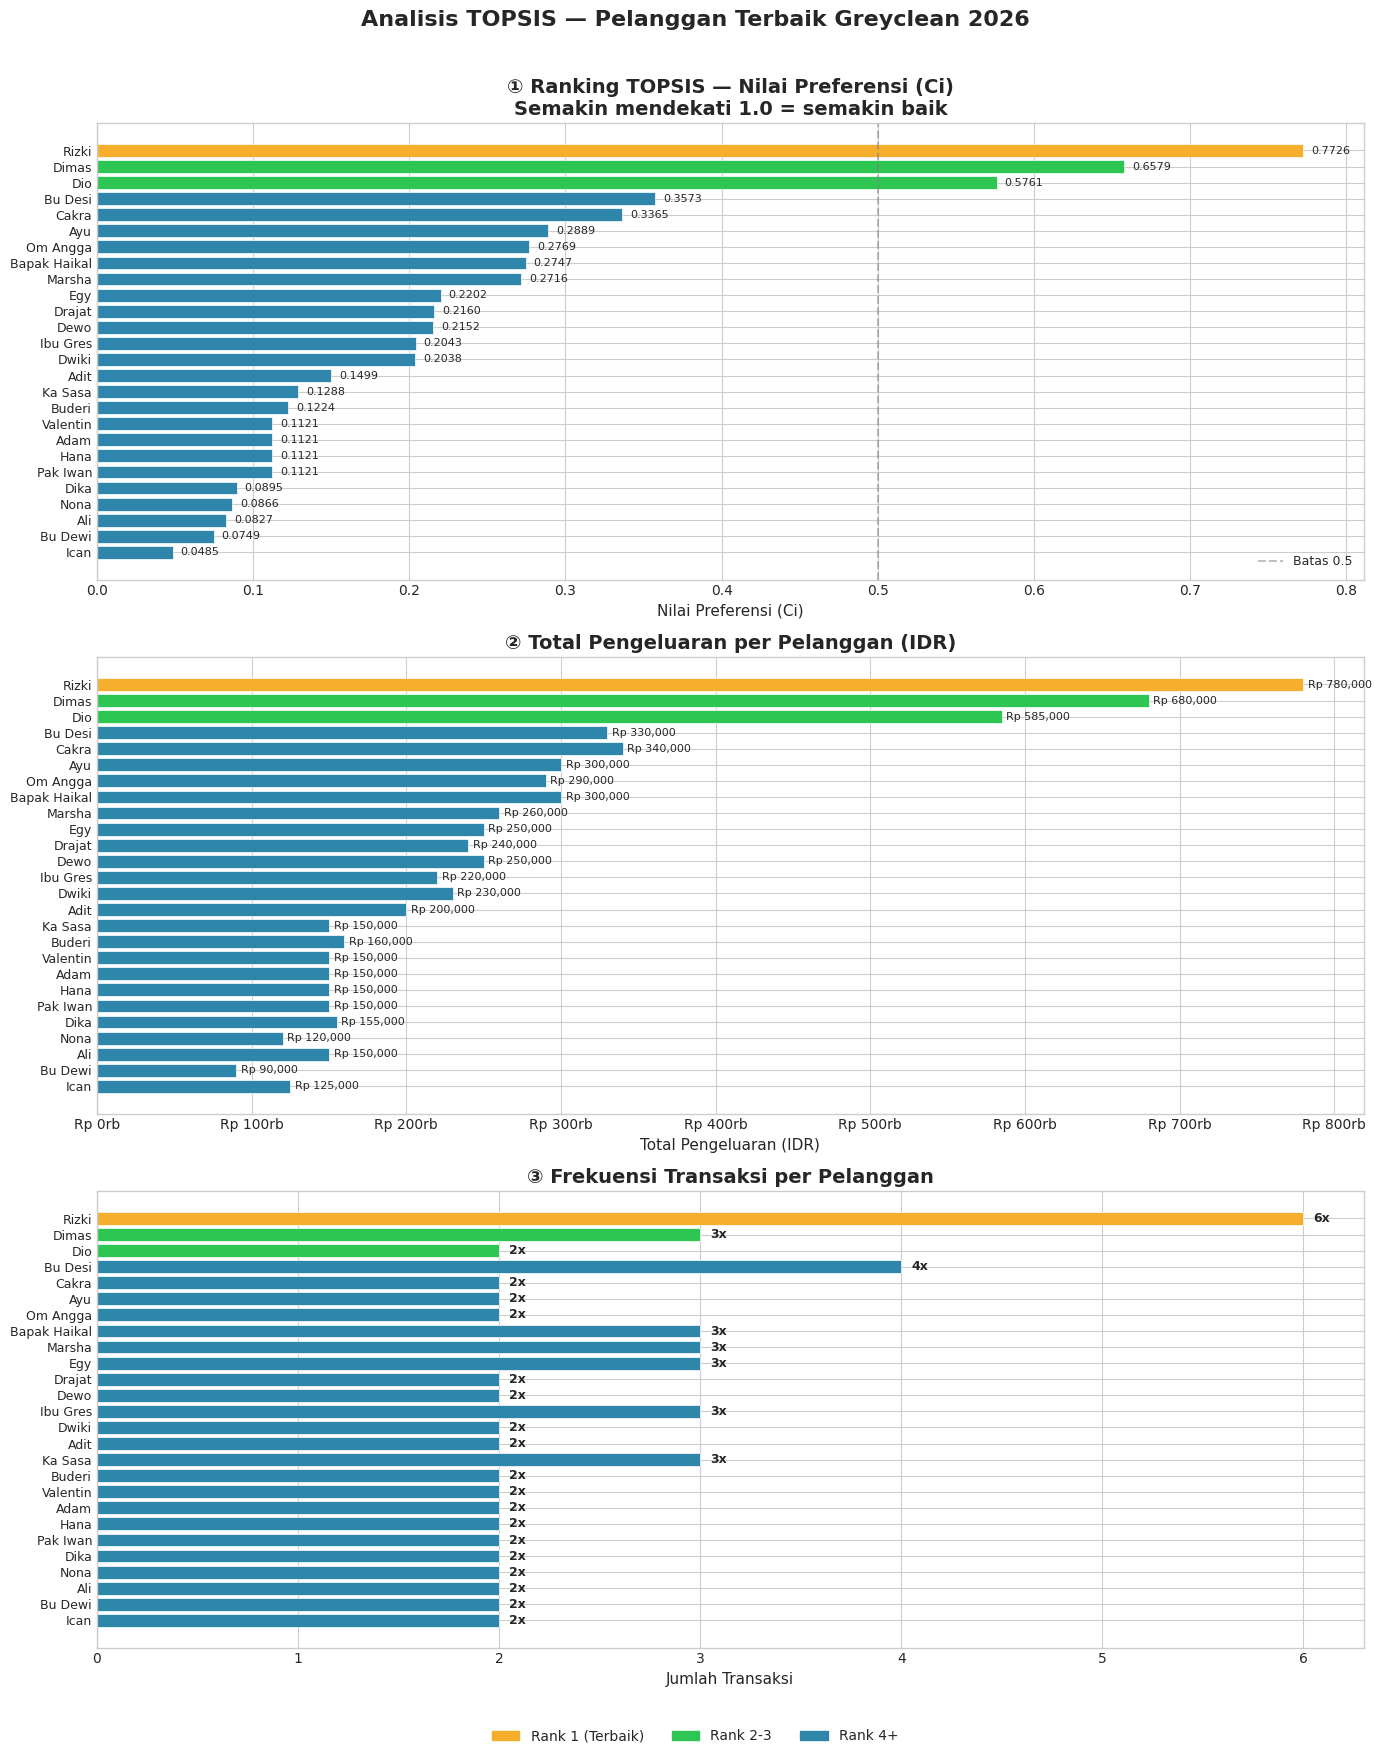

In [13]:
# ============================================================
# SEL 11: VISUALISASI
# ============================================================
# 3 grafik horizontal:
#   1. Ranking TOPSIS — Nilai Preferensi (Ci)
#   2. Total Pengeluaran per Pelanggan
#   3. Frekuensi Transaksi per Pelanggan

WARNA_UTAMA = '#2E86AB'
WARNA_EMAS  = '#F6AE2D'
WARNA_HIJAU = '#2DC653'

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Analisis TOPSIS — Pelanggan Terbaik Greyclean 2026',
             fontsize=16, fontweight='bold', y=0.98)

# Data terurut dari ranking terbaik
nama_urut  = df_hasil['Nama Pelanggan'].values
ci_urut    = df_hasil['Nilai Preferensi (Ci)'].values
harga_urut = df_hasil['C2_Total_Pengeluaran'].values
freq_urut  = df_hasil['C1_Total_Transaksi'].values

# Warna: emas rank 1, hijau rank 2-3, biru sisanya
warna = [WARNA_EMAS  if i == 0 else
         WARNA_HIJAU if i < 3  else
         WARNA_UTAMA for i in range(len(nama_urut))]

# ---- Grafik 1: Nilai Preferensi ----
ax1 = axes[0]
bars1 = ax1.barh(range(len(nama_urut)), ci_urut[::-1],
                 color=warna[::-1], edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(nama_urut)))
ax1.set_yticklabels(nama_urut[::-1], fontsize=9)
ax1.set_xlabel('Nilai Preferensi (Ci)')
ax1.set_title('① Ranking TOPSIS — Nilai Preferensi (Ci)\n'
              'Semakin mendekati 1.0 = semakin baik', fontweight='bold')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Batas 0.5')
ax1.legend(fontsize=9)
for bar, val in zip(bars1, ci_urut[::-1]):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)

# ---- Grafik 2: Total Pengeluaran ----
ax2 = axes[1]
bars2 = ax2.barh(range(len(nama_urut)), harga_urut[::-1],
                 color=warna[::-1], edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(nama_urut)))
ax2.set_yticklabels(nama_urut[::-1], fontsize=9)
ax2.set_xlabel('Total Pengeluaran (IDR)')
ax2.set_title('② Total Pengeluaran per Pelanggan (IDR)', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1000:.0f}rb'
))
for bar, val in zip(bars2, harga_urut[::-1]):
    ax2.text(val + 3000, bar.get_y() + bar.get_height()/2,
             f'Rp {val:,.0f}', va='center', fontsize=8)

# ---- Grafik 3: Frekuensi Transaksi ----
ax3 = axes[2]
bars3 = ax3.barh(range(len(nama_urut)), freq_urut[::-1],
                 color=warna[::-1], edgecolor='white', linewidth=0.5)
ax3.set_yticks(range(len(nama_urut)))
ax3.set_yticklabels(nama_urut[::-1], fontsize=9)
ax3.set_xlabel('Jumlah Transaksi')
ax3.set_title('③ Frekuensi Transaksi per Pelanggan', fontweight='bold')
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar, val in zip(bars3, freq_urut[::-1]):
    ax3.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val}x', va='center', fontsize=9, fontweight='bold')

# Legend warna
import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color=WARNA_EMAS,  label='Rank 1 (Terbaik)'),
    mpatches.Patch(color=WARNA_HIJAU, label='Rank 2-3'),
    mpatches.Patch(color=WARNA_UTAMA, label='Rank 4+')
]
fig.legend(handles=legend_items, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('TOPSIS_Greyclean_2026.png', dpi=150, bbox_inches='tight')
print('✅ Grafik disimpan: TOPSIS_Greyclean_2026.png')
plt.show()

In [14]:
# ============================================================
# SEL 12: KESIMPULAN ANALISIS
# ============================================================

terbaik       = df_hasil.iloc[0]
nama_terbaik  = terbaik['Nama Pelanggan']
ci_terbaik    = terbaik['Nilai Preferensi (Ci)']
freq_terbaik  = int(terbaik['C1_Total_Transaksi'])
total_terbaik = terbaik['C2_Total_Pengeluaran']
rata_terbaik  = terbaik['C3_Rata_Rata_Harga']
var_terbaik   = int(terbaik['C4_Variasi_Treatment'])

print('=' * 70)
print('  KESIMPULAN ANALISIS TOPSIS')
print('  Penentuan Pelanggan Terbaik — Greyclean 2026')
print('=' * 70)

print(f'''
  📌 LATAR BELAKANG
  Analisis ini menggunakan metode TOPSIS untuk menentukan pelanggan
  terbaik dari data transaksi laundry Greyclean periode Jan–Apr 2026.
  Dari total {len(df_all)} transaksi, terdapat {len(pelanggan_loyal)} pelanggan
  dengan frekuensi ≥ 2 kali yang masuk ke dalam analisis.

  📊 KRITERIA YANG DIGUNAKAN
  ┌─────────────────────────────────┬──────────┬───────────┐
  │ Kriteria                        │ Tipe     │ Bobot     │
  ├─────────────────────────────────┼──────────┼───────────┤
  │ C1 — Total Transaksi            │ Benefit  │ {bobot[0]*100:.0f}%      │
  │ C2 — Total Pengeluaran          │ Benefit  │ {bobot[1]*100:.0f}%      │
  │ C3 — Rata-rata Harga            │ Benefit  │ {bobot[2]*100:.0f}%      │
  │ C4 — Variasi Treatment          │ Benefit  │ {bobot[3]*100:.0f}%      │
  └─────────────────────────────────┴──────────┴───────────┘
''')

print('  🏆 PELANGGAN TERBAIK BERDASARKAN TOPSIS')
print(f'  ┌──────────────────────────────────────────────────┐')
print(f'  │  🥇  {nama_terbaik:<44s}│')
print(f'  ├──────────────────────────────────────────────────┤')
print(f'  │  Nilai Preferensi (Ci)  : {ci_terbaik:.4f} ({ci_terbaik*100:.2f}%)       │')
print(f'  │  Frekuensi Transaksi    : {freq_terbaik} kali                    │')
print(f'  │  Total Pengeluaran      : Rp {total_terbaik:,.0f}               │')
print(f'  │  Rata-rata per Kunjungan: Rp {rata_terbaik:,.0f}              │')
print(f'  │  Variasi Treatment      : {var_terbaik} jenis                   │')
print(f'  └──────────────────────────────────────────────────┘')

print(f'''
  📋 INTERPRETASI HASIL
  • {nama_terbaik} meraih peringkat 1 dengan nilai Ci = {ci_terbaik:.4f},
    artinya {ci_terbaik*100:.1f}% mendekati kondisi pelanggan ideal.
  • Pelanggan ini unggul pada frekuensi transaksi dan total pengeluaran
    yang melampaui rata-rata pelanggan lain.

  💡 REKOMENDASI BISNIS
  1. Berikan program loyalitas atau reward kepada TOP 3 pelanggan
     untuk mempertahankan dan meningkatkan transaksi mereka.
  2. Jadikan profil {nama_terbaik} sebagai acuan pelanggan ideal
     untuk strategi akuisisi pelanggan baru.
  3. Pelanggan dengan variasi treatment rendah dapat ditingkatkan
     melalui promo cross-selling layanan.
  4. Lakukan analisis ulang setiap kuartal untuk memantau perubahan
     perilaku pelanggan secara berkala.

  ⚠️  CATATAN METODOLOGI
  Analisis hanya mencakup pelanggan ≥ 2 transaksi agar penilaian
  TOPSIS lebih bermakna. Pelanggan 1x transaksi tidak diikutsertakan
  karena datanya belum cukup untuk menilai loyalitas.
''')

print('=' * 70)
print('  SELESAI — Analisis TOPSIS Greyclean 2026')
print('=' * 70)

  KESIMPULAN ANALISIS TOPSIS
  Penentuan Pelanggan Terbaik — Greyclean 2026

  📌 LATAR BELAKANG
  Analisis ini menggunakan metode TOPSIS untuk menentukan pelanggan
  terbaik dari data transaksi laundry Greyclean periode Jan–Apr 2026.
  Dari total 196 transaksi, terdapat 26 pelanggan
  dengan frekuensi ≥ 2 kali yang masuk ke dalam analisis.

  📊 KRITERIA YANG DIGUNAKAN
  ┌─────────────────────────────────┬──────────┬───────────┐
  │ Kriteria                        │ Tipe     │ Bobot     │
  ├─────────────────────────────────┼──────────┼───────────┤
  │ C1 — Total Transaksi            │ Benefit  │ 30%      │
  │ C2 — Total Pengeluaran          │ Benefit  │ 35%      │
  │ C3 — Rata-rata Harga            │ Benefit  │ 20%      │
  │ C4 — Variasi Treatment          │ Benefit  │ 15%      │
  └─────────────────────────────────┴──────────┴───────────┘

  🏆 PELANGGAN TERBAIK BERDASARKAN TOPSIS
  ┌──────────────────────────────────────────────────┐
  │  🥇  Rizki                                   